# Experiment 2: Spam Classification (Naive Bayes vs KNN)

Spambase dataset. Gaussian/Multinomial/Bernoulli Naive Bayes vs a tuned KNN.

In [1]:
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, auc, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['legend.title_fontsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

HAM_COLOR, SPAM_COLOR = "#4C72B0", "#C44E52"
ACC_COLOR, F1_COLOR = "#4C72B0", "#DD8452"

## Load the data

In [3]:
WORDS = ["make","address","all","3d","our","over","remove","internet","order","mail",
"receive","will","people","report","addresses","free","business","email","you","credit",
"your","font","000","money","hp","hpl","george","650","lab","labs","telnet","857","data",
"415","85","technology","1999","parts","pm","direct","cs","meeting","original","project",
"re","edu","table","conference"]
CHARS = [";","(","[","!","$","#"]
COL_NAMES = ([f"word_freq_{w}" for w in WORDS] + [f"char_freq_{c}" for c in CHARS] +
             ["capital_run_length_average","capital_run_length_longest",
              "capital_run_length_total","is_spam"])

df = pd.read_csv("spambase.data", header=None, names=COL_NAMES)
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Class distribution:\n", df["is_spam"].value_counts())

X_raw = df.drop(columns=["is_spam"]).values
y = df["is_spam"].values
feature_names = df.drop(columns=["is_spam"]).columns.tolist()

Dataset shape: (4601, 58)
Missing values: 0
Class distribution:
 is_spam
0    2788
1    1813
Name: count, dtype: int64


## EDA

Top correlated features with label:
 word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_$                 0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
word_freq_hp               -0.256723
capital_run_length_total    0.249164
word_freq_our               0.241920
Name: is_spam, dtype: float64


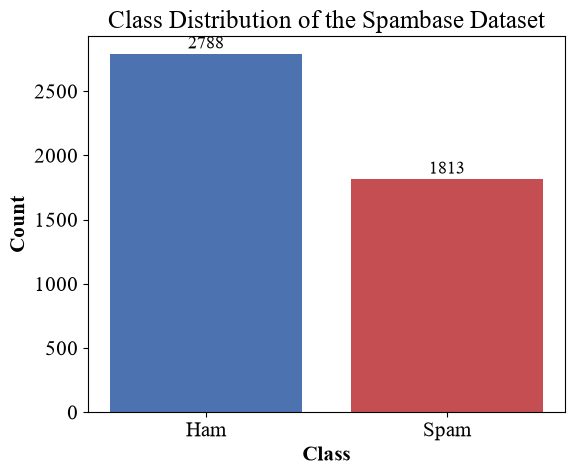

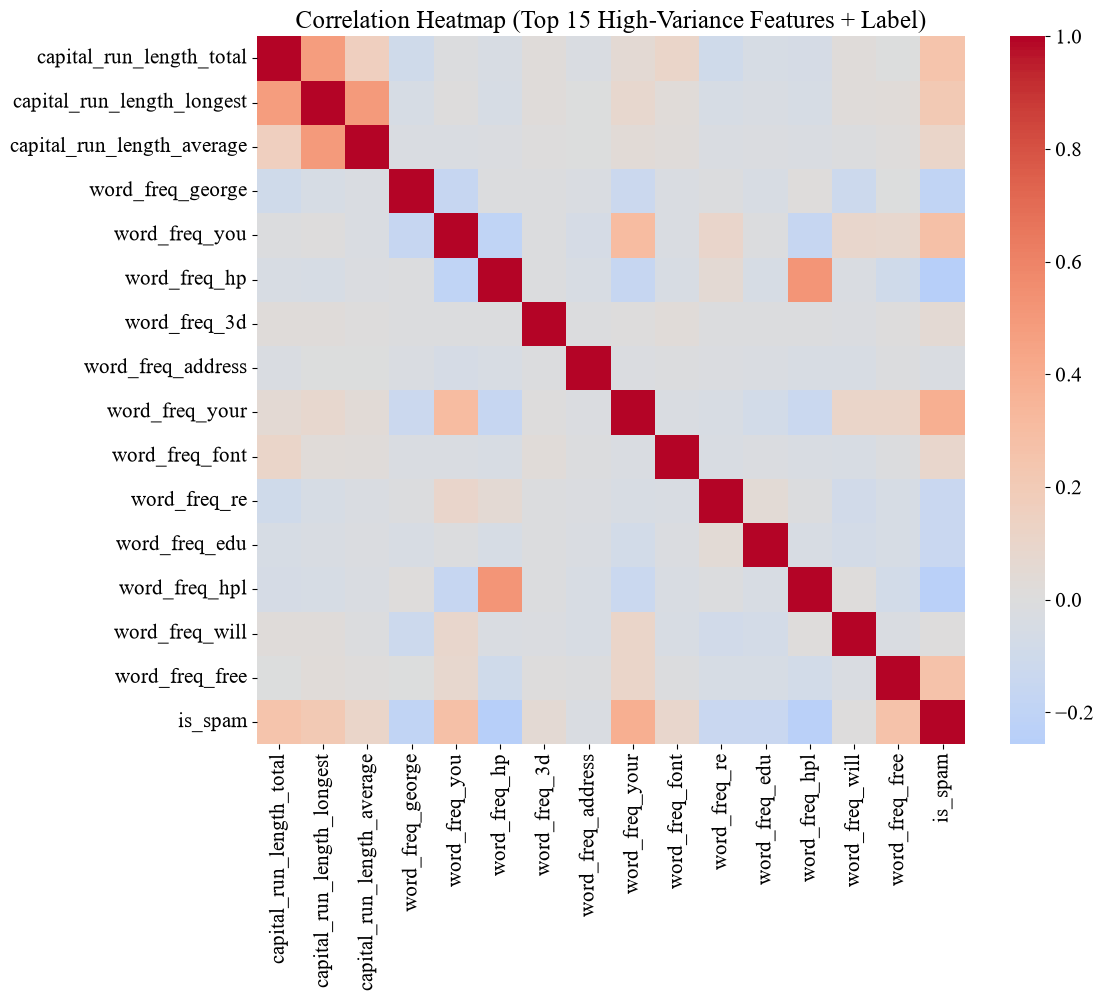

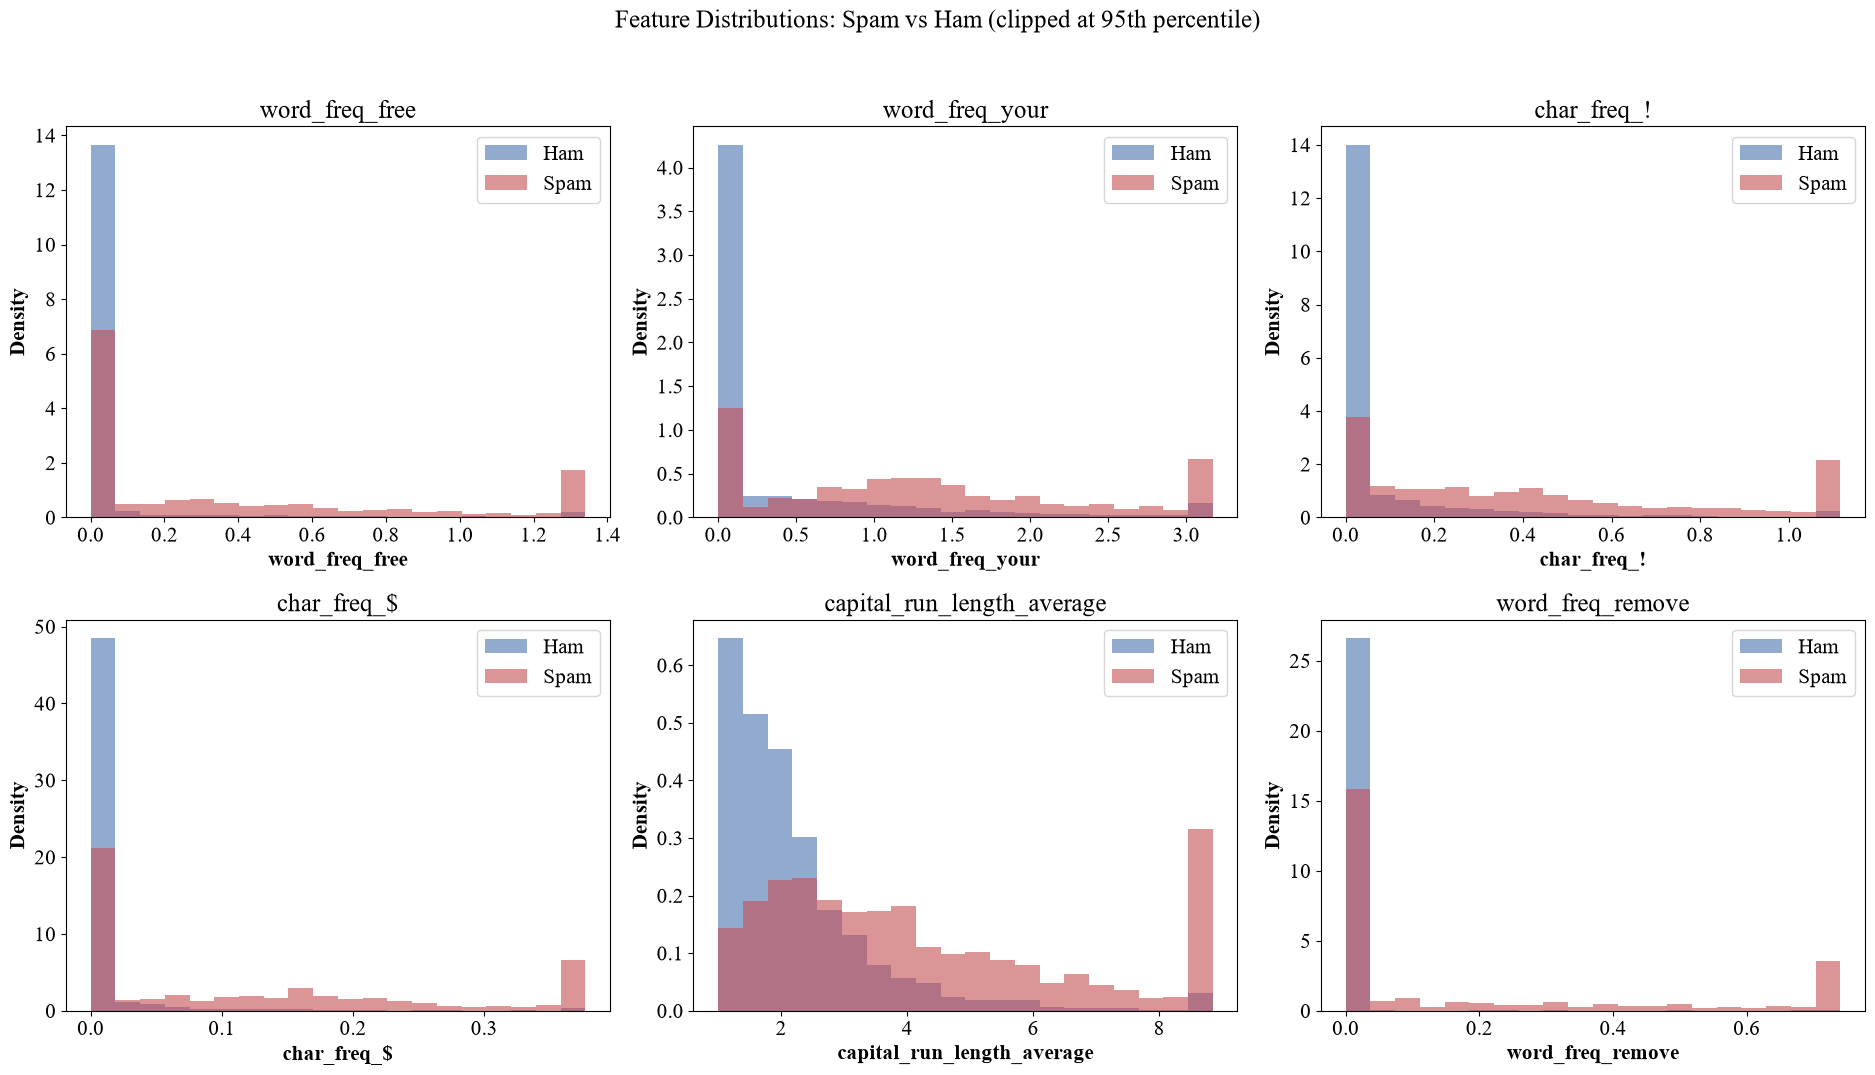

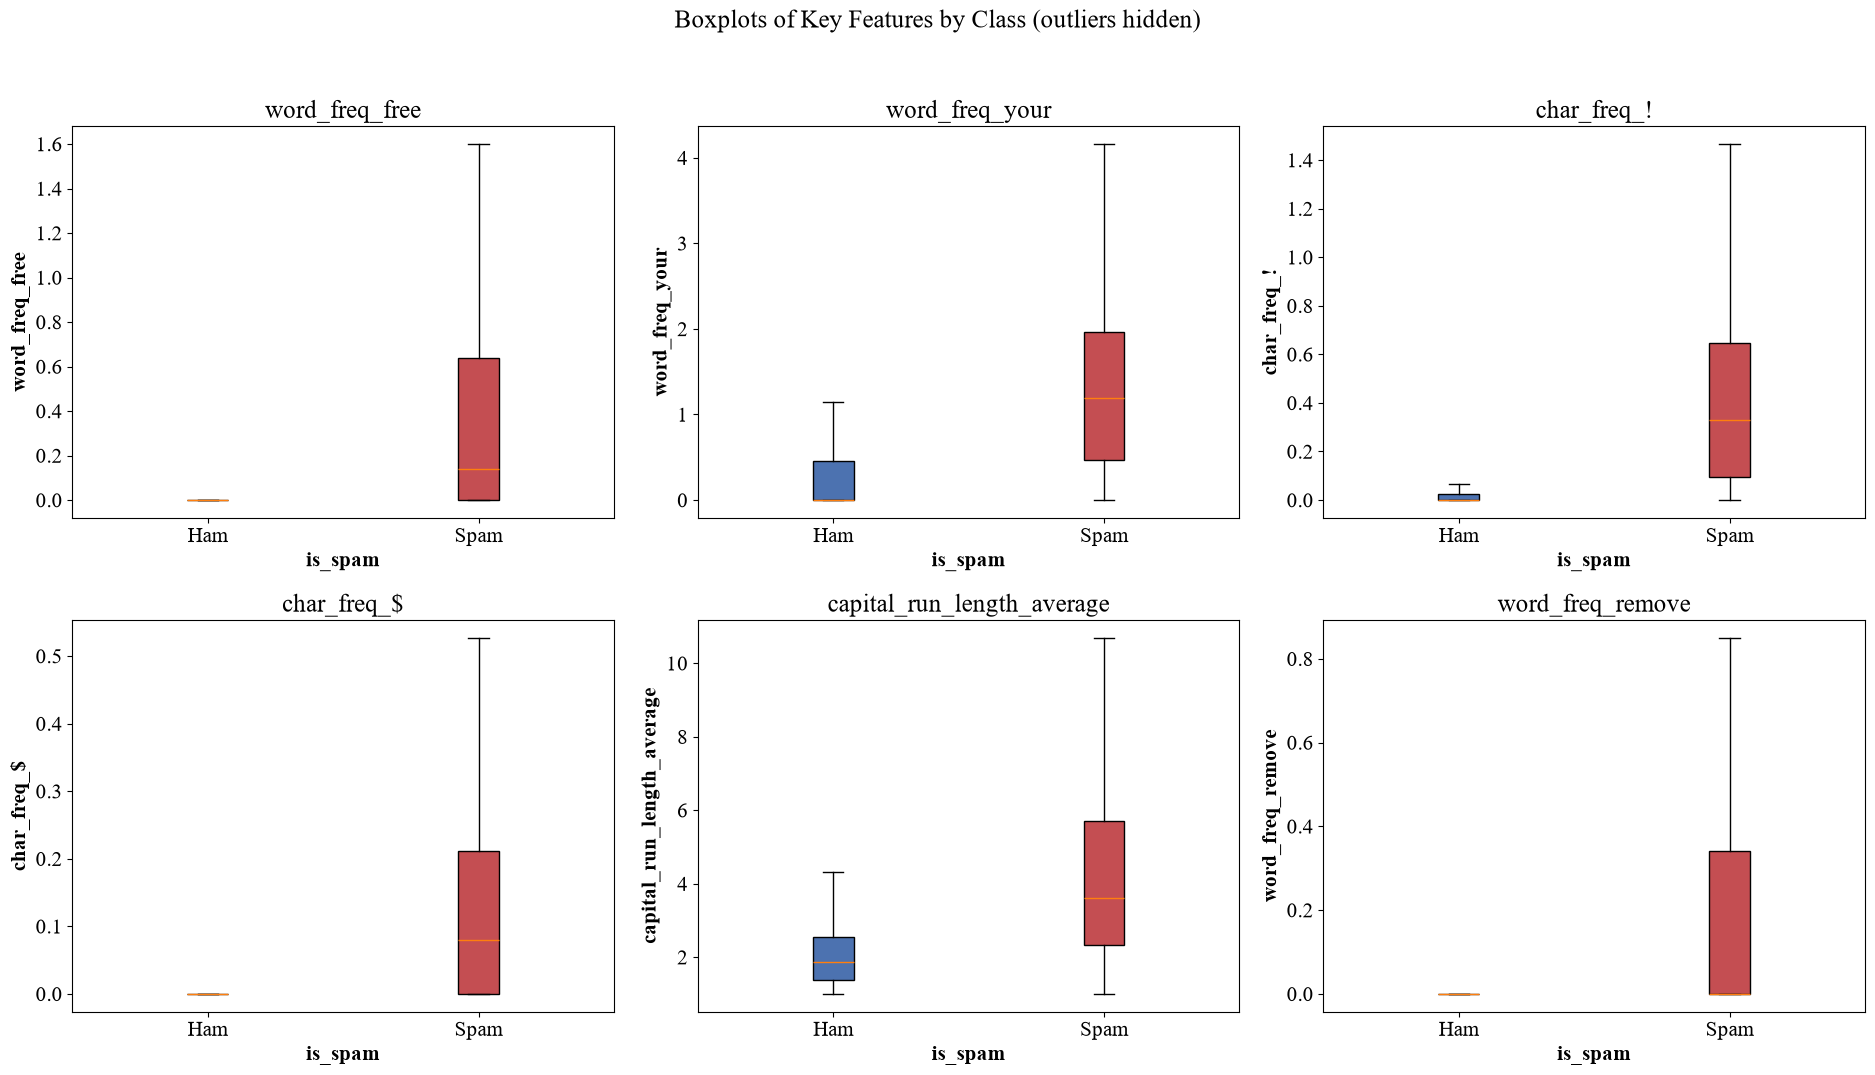

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


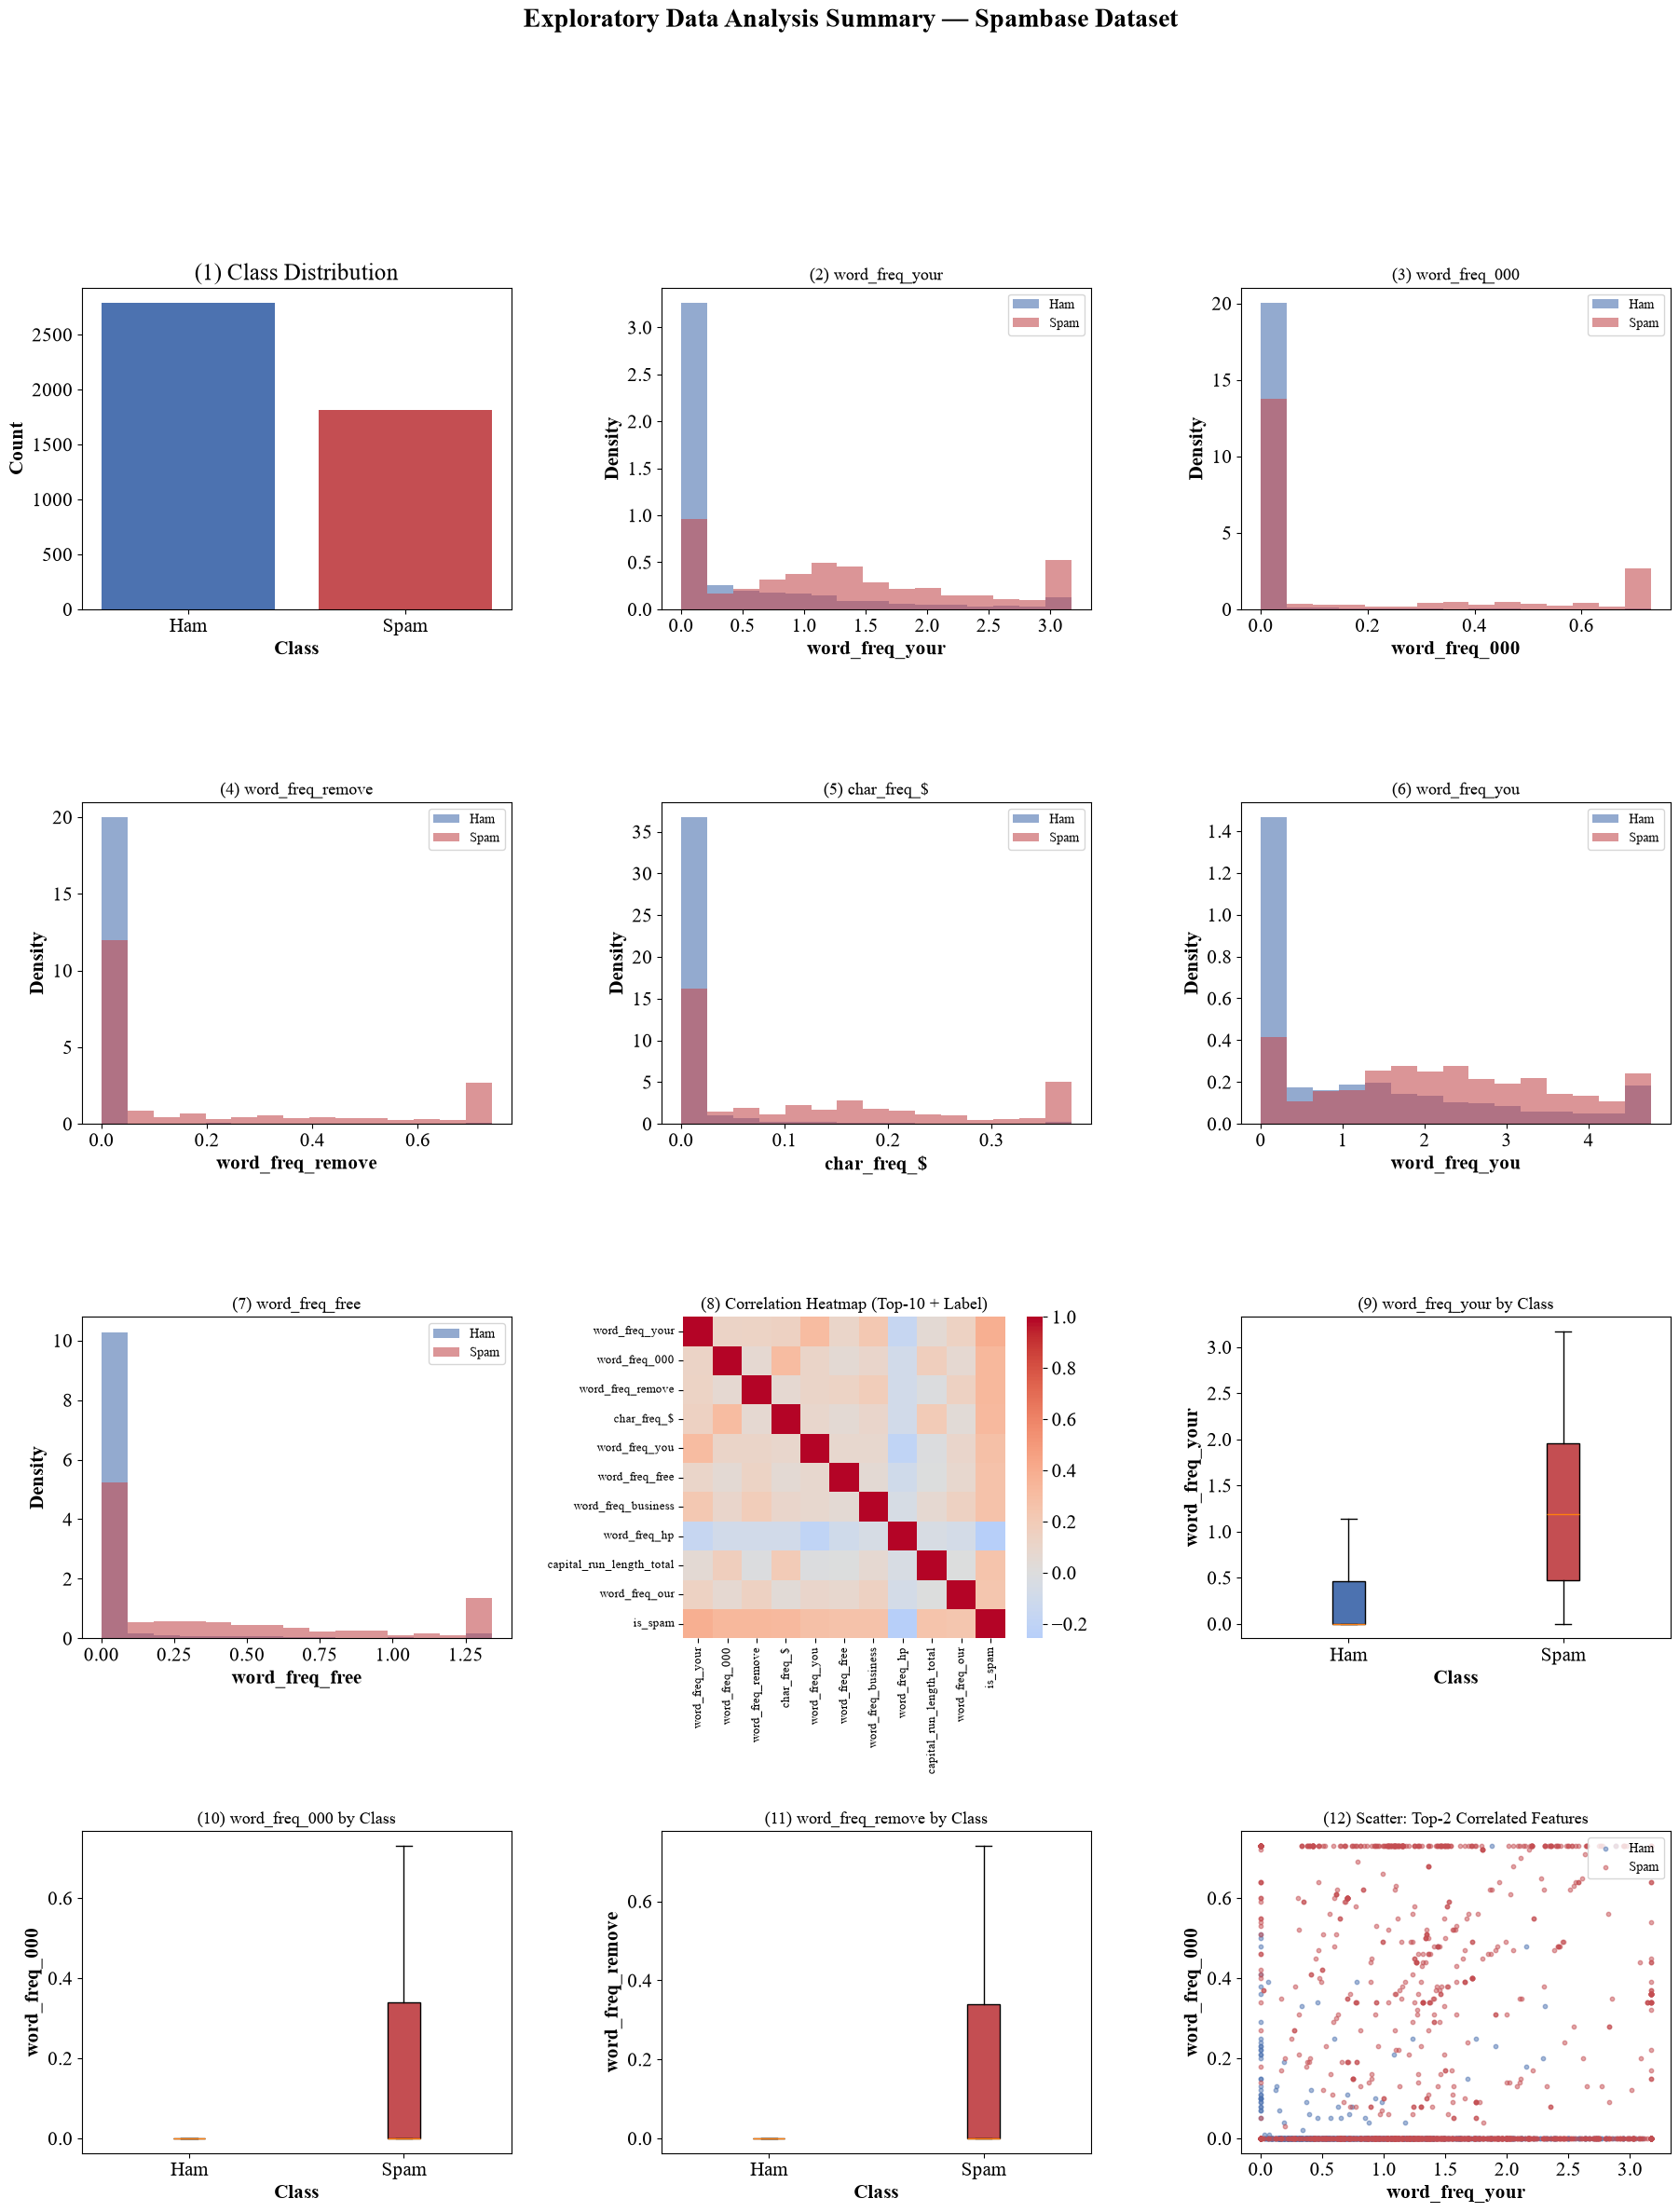

Saved consolidated EDA summary figure (EPS @600dpi + PNG @150dpi).


In [4]:
corr = df.corr()["is_spam"].drop("is_spam")
top_feats = corr.abs().sort_values(ascending=False).index.tolist()
print("Top correlated features with label:\n", corr.reindex(top_feats).head(10))

variances = pd.Series(X_raw.var(axis=0), index=feature_names).sort_values(ascending=False)
highvar_feats = variances.head(15).index.tolist()

counts = df["is_spam"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Ham", "Spam"], counts.values, color=[HAM_COLOR, SPAM_COLOR])
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 15, str(int(b.get_height())),
            ha="center", va="bottom", fontsize=13)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Class Distribution of the Spambase Dataset")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/01_class_distribution.png", dpi=150)
plt.show()
plt.close(fig)

heatmap_cols = highvar_feats + ["is_spam"]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[heatmap_cols].corr(), cmap="coolwarm", center=0, square=True,
            cbar=True, ax=ax)
ax.set_title("Correlation Heatmap (Top 15 High-Variance Features + Label)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_correlation_heatmap.png", dpi=150)
plt.show()
plt.close(fig)

hist_feats = ["word_freq_free", "word_freq_your", "char_freq_!", "char_freq_$",
              "capital_run_length_average", "word_freq_remove"]
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
for feat, ax in zip(hist_feats, axes.ravel()):
    clip_val = df[feat].quantile(0.95)
    for cls, label, color in [(0, "Ham", HAM_COLOR), (1, "Spam", SPAM_COLOR)]:
        vals = df.loc[df["is_spam"] == cls, feat].clip(upper=clip_val)
        ax.hist(vals, bins=20, alpha=0.6, label=label, color=color, density=True)
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.set_title(feat)
    ax.legend()
fig.suptitle("Feature Distributions: Spam vs Ham (clipped at 95th percentile)")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(f"{FIG_DIR}/03_histograms.png", dpi=150)
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
for feat, ax in zip(hist_feats, axes.ravel()):
    ham_vals = df.loc[df["is_spam"] == 0, feat]
    spam_vals = df.loc[df["is_spam"] == 1, feat]
    bp = ax.boxplot([ham_vals, spam_vals], tick_labels=["Ham", "Spam"], showfliers=False,
                     patch_artist=True)
    for patch, color in zip(bp["boxes"], [HAM_COLOR, SPAM_COLOR]):
        patch.set_facecolor(color)
    ax.set_xlabel("is_spam")
    ax.set_ylabel(feat)
    ax.set_title(feat)
fig.suptitle("Boxplots of Key Features by Class (outliers hidden)")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(f"{FIG_DIR}/04_boxplots.png", dpi=150)
plt.show()
plt.close(fig)

def build_eda_summary_figure(df, top_feats):
    fig = plt.figure(figsize=(22, 26))
    gs = fig.add_gridspec(4, 3, hspace=0.6, wspace=0.35)

    ax = fig.add_subplot(gs[0, 0])
    counts = df["is_spam"].value_counts().sort_index()
    ax.bar(["Ham", "Spam"], counts.values, color=[HAM_COLOR, SPAM_COLOR])
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_title("(1) Class Distribution")

    hist_feats_local = top_feats[:6]
    hist_positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0)]
    for i, (feat, pos) in enumerate(zip(hist_feats_local, hist_positions)):
        ax = fig.add_subplot(gs[pos])
        clip_val = df[feat].quantile(0.95)
        for cls, label, color in [(0, "Ham", HAM_COLOR), (1, "Spam", SPAM_COLOR)]:
            vals = df.loc[df["is_spam"] == cls, feat].clip(upper=clip_val)
            ax.hist(vals, bins=15, alpha=0.6, label=label, color=color, density=True)
        ax.set_xlabel(feat)
        ax.set_ylabel("Density")
        ax.set_title(f"({i + 2}) {feat}", fontsize=13)
        ax.legend(fontsize=10)

    ax = fig.add_subplot(gs[2, 1])
    heat_cols = top_feats[:10] + ["is_spam"]
    sns.heatmap(df[heat_cols].corr(), cmap="coolwarm", center=0, ax=ax,
                cbar=True, annot=False, square=True)
    ax.set_title("(8) Correlation Heatmap (Top-10 + Label)", fontsize=13)
    ax.tick_params(axis='x', labelsize=9, rotation=90)
    ax.tick_params(axis='y', labelsize=9)

    box_feats = top_feats[:3]
    box_positions = [(2, 2), (3, 0), (3, 1)]
    for i, (feat, pos) in enumerate(zip(box_feats, box_positions)):
        ax = fig.add_subplot(gs[pos])
        clip_val = df[feat].quantile(0.95)
        ham_vals = df.loc[df["is_spam"] == 0, feat].clip(upper=clip_val)
        spam_vals = df.loc[df["is_spam"] == 1, feat].clip(upper=clip_val)
        bp = ax.boxplot([ham_vals, spam_vals], tick_labels=["Ham", "Spam"],
                         showfliers=False, patch_artist=True)
        for patch, color in zip(bp["boxes"], [HAM_COLOR, SPAM_COLOR]):
            patch.set_facecolor(color)
        ax.set_xlabel("Class")
        ax.set_ylabel(feat)
        ax.set_title(f"({i + 9}) {feat} by Class", fontsize=13)

    ax = fig.add_subplot(gs[3, 2])
    f1, f2 = top_feats[0], top_feats[1]
    clip1, clip2 = df[f1].quantile(0.95), df[f2].quantile(0.95)
    for cls, label, color in [(0, "Ham", HAM_COLOR), (1, "Spam", SPAM_COLOR)]:
        sub = df[df["is_spam"] == cls]
        ax.scatter(sub[f1].clip(upper=clip1), sub[f2].clip(upper=clip2),
                   s=10, alpha=0.5, label=label, color=color)
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.set_title("(12) Scatter: Top-2 Correlated Features", fontsize=13)
    ax.legend(fontsize=10)

    fig.suptitle("Exploratory Data Analysis Summary — Spambase Dataset",
                 fontsize=20, fontweight="bold", y=0.995)
    return fig

eda_top_feats = top_feats[:10]
eda_fig = build_eda_summary_figure(df, eda_top_feats)
eda_fig.savefig(f"{FIG_DIR}/00_eda_summary.eps", format="eps", dpi=600)
eda_fig.savefig(f"{FIG_DIR}/00_eda_summary.png", dpi=150)
plt.show()
plt.close(eda_fig)
print("Saved consolidated EDA summary figure (EPS @600dpi + PNG @150dpi).")

## Preprocessing

In [5]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=42)

scaler = StandardScaler().fit(X_train_raw)
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

def evaluate(y_true, y_pred, y_score=None):
    d = dict(accuracy=accuracy_score(y_true, y_pred),
             precision=precision_score(y_true, y_pred),
             recall=recall_score(y_true, y_pred),
             f1=f1_score(y_true, y_pred))
    if y_score is not None:
        d["roc_auc"] = roc_auc_score(y_true, y_score)
    return d

def train_and_evaluate_classifier(model, X_train, y_train, X_test, y_test):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_time = time.perf_counter() - t0

    y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = evaluate(y_test, y_pred, y_score)
    metrics["train_time"] = train_time
    metrics["predict_time"] = predict_time
    return {"model": model, "y_pred": y_pred, "y_score": y_score, "metrics": metrics}

## Naive Bayes

In [6]:
results_nb = {}
nb_models, nb_preds, nb_scores = {}, {}, {}
for name, model, Xtr, Xte in [
        ("Gaussian",     GaussianNB(),     X_train_scaled, X_test_scaled),
        ("Multinomial",  MultinomialNB(),  X_train_raw,    X_test_raw),
        ("Bernoulli",    BernoulliNB(),    X_train_raw,    X_test_raw)]:
    res = train_and_evaluate_classifier(model, Xtr, y_train, Xte, y_test)
    results_nb[name] = res["metrics"]
    nb_models[name], nb_preds[name], nb_scores[name] = model, res["y_pred"], res["y_score"]
    print(name, "NB:", results_nb[name])

best_nb_name = max(results_nb, key=lambda k: results_nb[k]["f1"])

Gaussian NB: {'accuracy': 0.8327904451682954, 'precision': 0.7145790554414785, 'recall': 0.9586776859504132, 'f1': 0.8188235294117647, 'roc_auc': 0.9376116986087661, 'train_time': 0.0022650999890174717, 'predict_time': 0.00047130000893957913}
Multinomial NB: {'accuracy': 0.7763300760043431, 'precision': 0.7198879551820728, 'recall': 0.7079889807162535, 'f1': 0.7138888888888889, 'roc_auc': 0.8248121488590697, 'train_time': 0.0010980000079143792, 'predict_time': 0.00014739998732693493}
Bernoulli NB: {'accuracy': 0.8762214983713354, 'precision': 0.8716417910447761, 'recall': 0.8044077134986226, 'f1': 0.836676217765043, 'roc_auc': 0.9496455266249987, 'train_time': 0.002590399992186576, 'predict_time': 0.000512500002514571}


## KNN

In [7]:
knn_k_results = {}
for k in [1, 3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    res = train_and_evaluate_classifier(knn, X_train_scaled, y_train, X_test_scaled, y_test)
    knn_k_results[k] = res["metrics"]

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {"n_neighbors": [1,3,5,7,9,11,13,15],
              "weights": ["uniform","distance"],
              "algorithm": ["kd_tree","ball_tree"],
              "metric": ["euclidean","manhattan"]}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print("GridSearchCV best:", grid.best_params_, grid.best_score_)

param_dist = {"n_neighbors": list(range(1, 26)),
              "weights": ["uniform","distance"],
              "algorithm": ["kd_tree","ball_tree"],
              "metric": ["euclidean","manhattan"]}
rand = RandomizedSearchCV(KNeighborsClassifier(), param_dist, n_iter=25, cv=cv5,
                           scoring="accuracy", random_state=42, n_jobs=-1)
rand.fit(X_train_scaled, y_train)
print("RandomizedSearchCV best:", rand.best_params_, rand.best_score_)

best_knn = KNeighborsClassifier(**grid.best_params_)
best_knn_res = train_and_evaluate_classifier(best_knn, X_train_scaled, y_train, X_test_scaled, y_test)
best_knn_metrics = best_knn_res["metrics"]
best_knn_pred = best_knn_res["y_pred"]
best_knn_score = best_knn_res["y_score"]
print("Best KNN test metrics:", best_knn_metrics)

GridSearchCV best: {'algorithm': 'kd_tree', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'} 0.9252717391304348


RandomizedSearchCV best: {'weights': 'distance', 'n_neighbors': 8, 'metric': 'manhattan', 'algorithm': 'ball_tree'} 0.9255434782608696
Best KNN test metrics: {'accuracy': 0.9207383279044516, 'precision': 0.9420731707317073, 'recall': 0.8512396694214877, 'f1': 0.894356005788712, 'roc_auc': 0.9712126149076296, 'train_time': 0.012064300011843443, 'predict_time': 0.09531660002539866}


## 5-fold CV comparison

In [8]:
nb_cv = cross_val_score(BernoulliNB(), X_train_raw, y_train, cv=cv5, scoring="accuracy")
knn_cv = cross_val_score(KNeighborsClassifier(**grid.best_params_),
                          X_train_scaled, y_train, cv=cv5, scoring="accuracy")
print("Bernoulli NB 5-fold CV:", nb_cv, nb_cv.mean())
print("Best KNN 5-fold CV:", knn_cv, knn_cv.mean())

Bernoulli NB 5-fold CV: [0.90625    0.89130435 0.87228261 0.86820652 0.89809783] 0.8872282608695652
Best KNN 5-fold CV: [0.9388587  0.92798913 0.92527174 0.92663043 0.9076087 ] 0.9252717391304348


## Plots

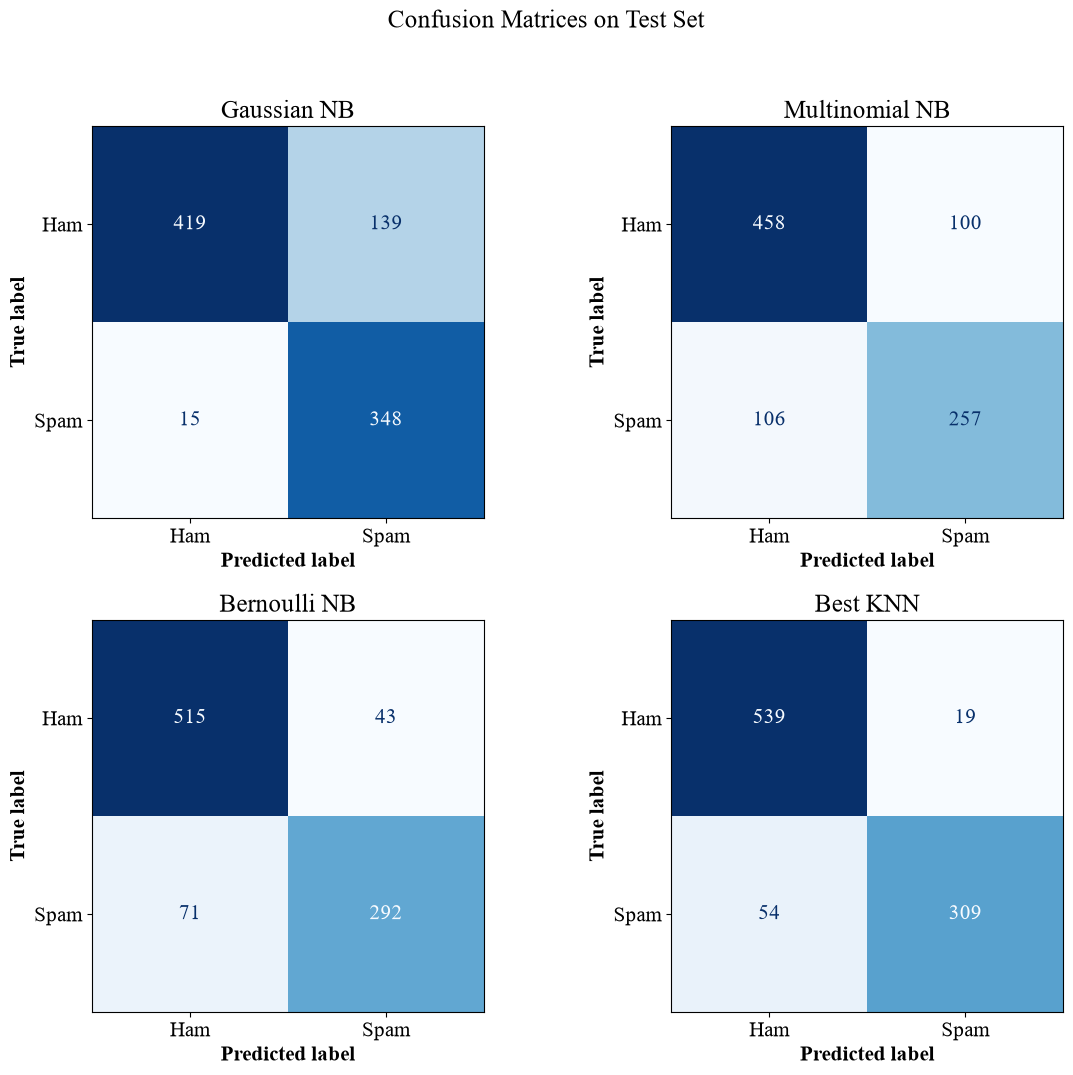

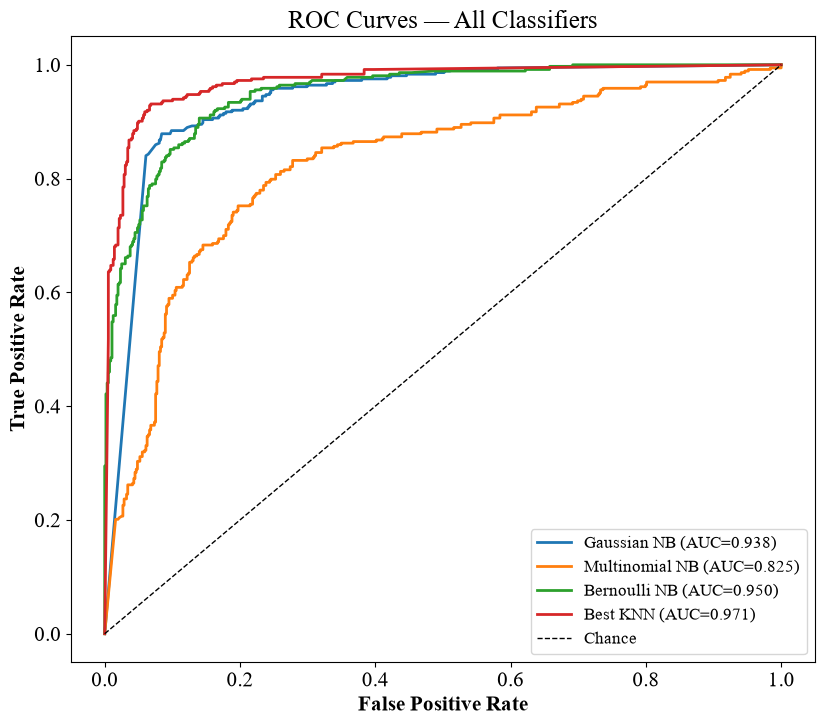

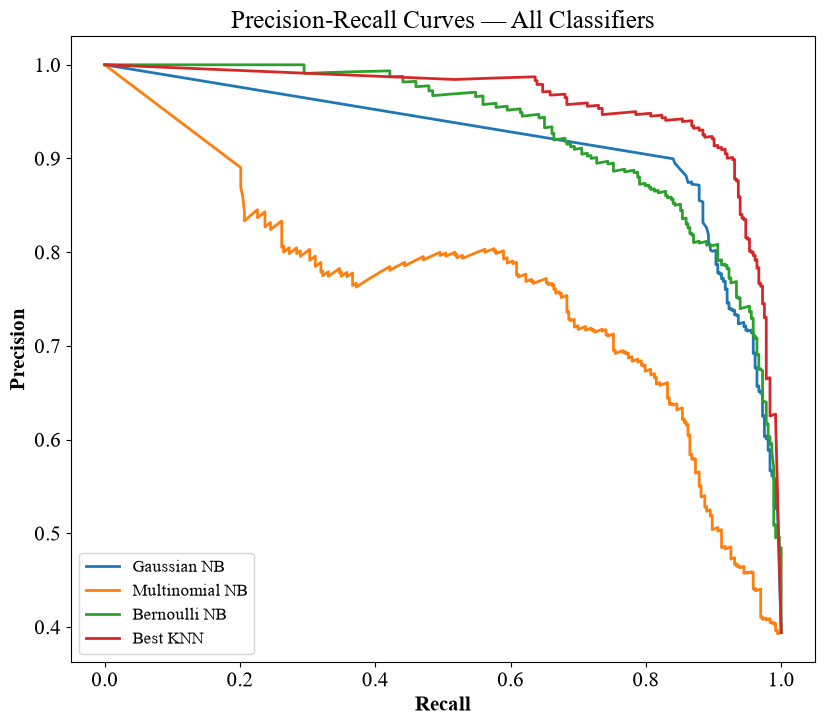

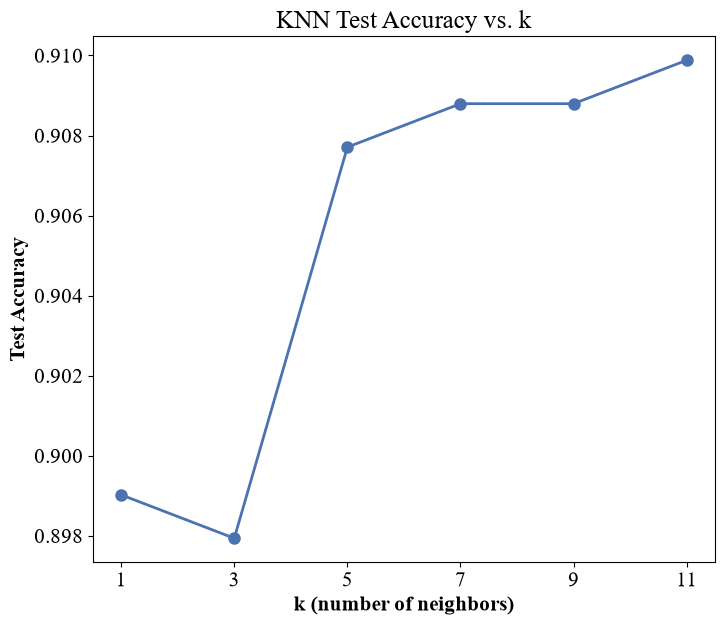

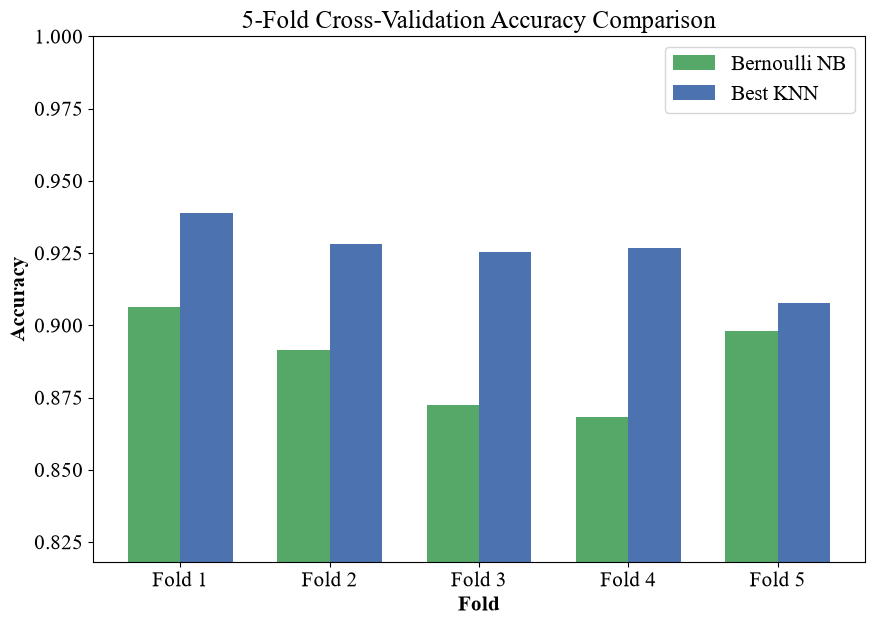

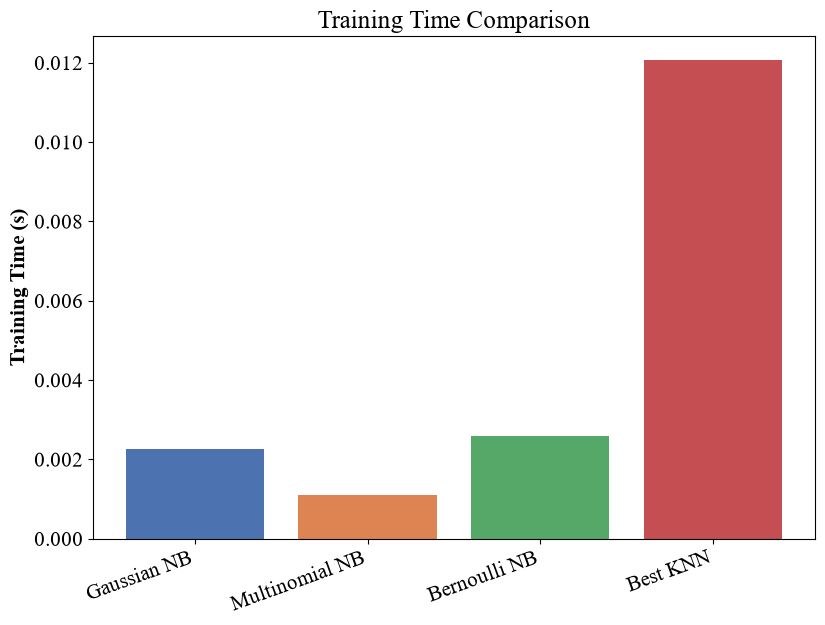

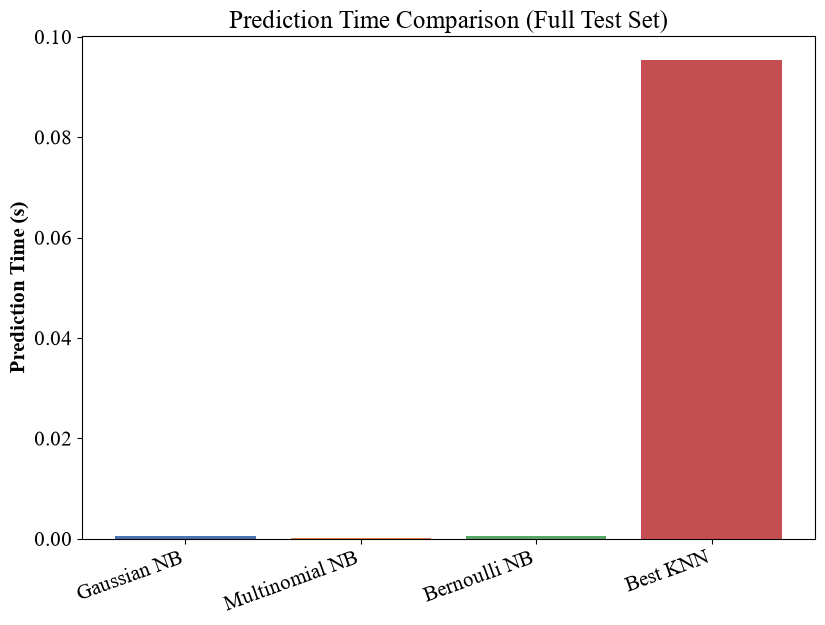

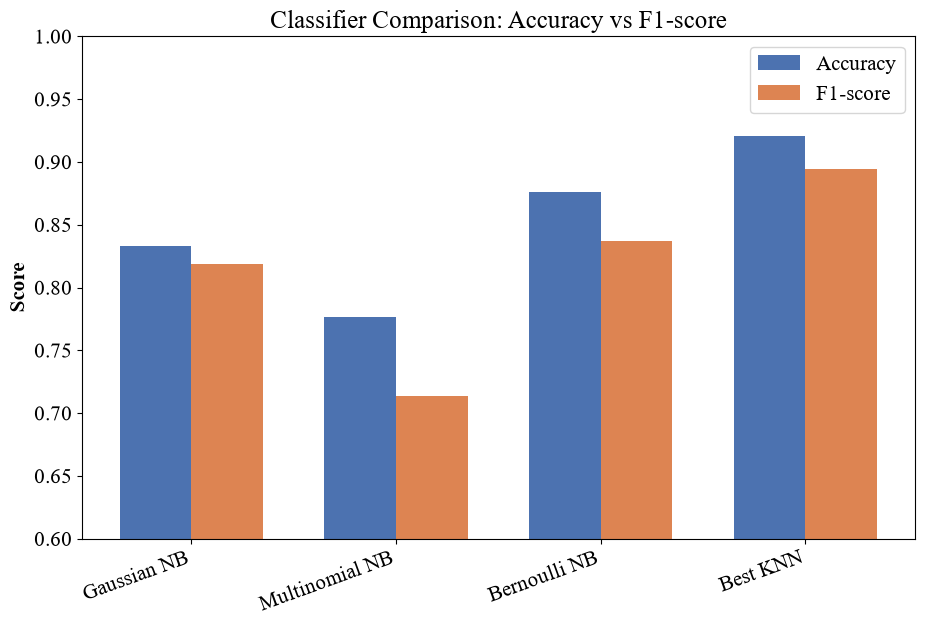

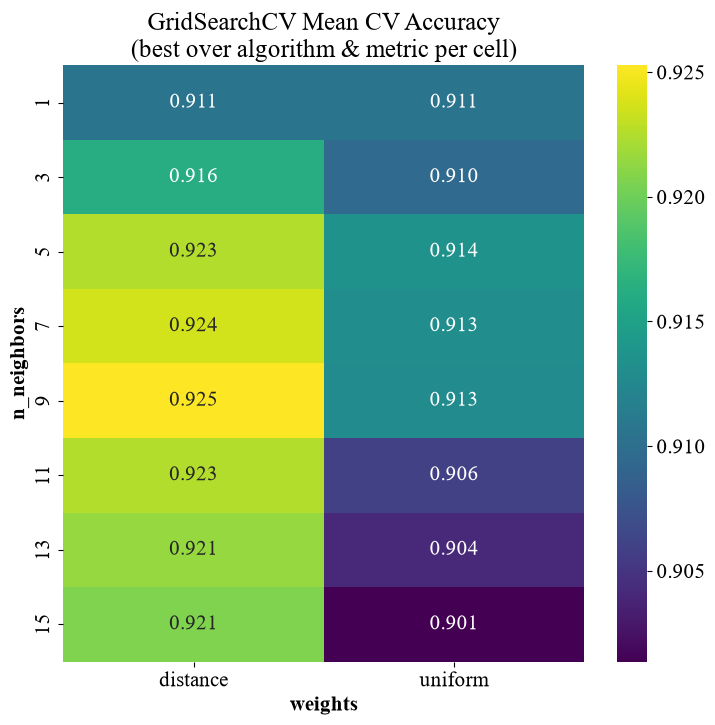

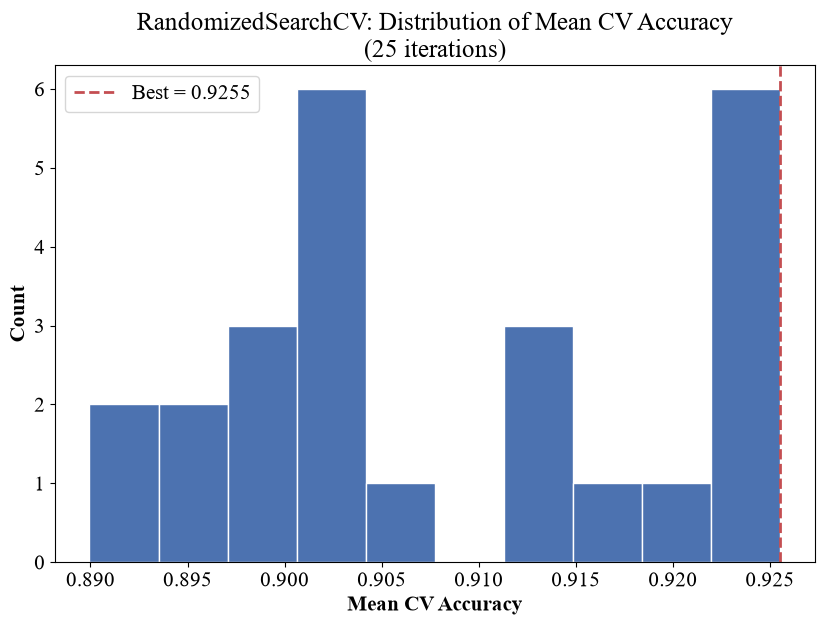


All 16 figures (00 EPS+PNG, 01-14 PNG) written to the 'figures/' directory.


In [9]:
clf_labels = ["Gaussian NB", "Multinomial NB", "Bernoulli NB", "Best KNN"]
clf_preds  = [nb_preds["Gaussian"], nb_preds["Multinomial"], nb_preds["Bernoulli"], best_knn_pred]
clf_scores = [nb_scores["Gaussian"], nb_scores["Multinomial"], nb_scores["Bernoulli"], best_knn_score]
clf_metrics = [results_nb["Gaussian"], results_nb["Multinomial"], results_nb["Bernoulli"], best_knn_metrics]
clf_bar_colors = [HAM_COLOR, "#DD8452", "#55A868", SPAM_COLOR]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for label, pred, ax in zip(clf_labels, clf_preds, axes.ravel()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(label)
fig.suptitle("Confusion Matrices on Test Set")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(f"{FIG_DIR}/05_confusion_matrices.png", dpi=150)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8.5, 7.5))
for label, score in zip(clf_labels, clf_scores):
    fpr, tpr, _ = roc_curve(y_test, score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Classifiers")
ax.legend(loc="lower right", fontsize=12)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_roc_curves.png", dpi=150)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8.5, 7.5))
for label, score in zip(clf_labels, clf_scores):
    precision, recall, _ = precision_recall_curve(y_test, score)
    ax.plot(recall, precision, label=label, linewidth=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Classifiers")
ax.legend(loc="lower left", fontsize=12)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_pr_curves.png", dpi=150)
plt.show()
plt.close(fig)

ks = sorted(knn_k_results.keys())
accs = [knn_k_results[k]["accuracy"] for k in ks]
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.plot(ks, accs, marker="o", markersize=8, linewidth=2, color=HAM_COLOR)
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("Test Accuracy")
ax.set_title("KNN Test Accuracy vs. k")
ax.set_xticks(ks)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/08_accuracy_vs_k.png", dpi=150)
plt.show()
plt.close(fig)

folds = np.arange(1, len(nb_cv) + 1)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.bar(folds - width / 2, nb_cv, width, label="Bernoulli NB", color="#55A868")
ax.bar(folds + width / 2, knn_cv, width, label="Best KNN", color=HAM_COLOR)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_xticks(folds)
ax.set_xticklabels([f"Fold {f}" for f in folds])
ax.set_ylim(min(nb_cv.min(), knn_cv.min()) - 0.05, 1.0)
ax.set_title("5-Fold Cross-Validation Accuracy Comparison")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/09_cv_accuracy.png", dpi=150)
plt.show()
plt.close(fig)

train_times = [m["train_time"] for m in clf_metrics]
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.bar(clf_labels, train_times, color=clf_bar_colors)
ax.set_ylabel("Training Time (s)")
ax.set_title("Training Time Comparison")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/10_training_time.png", dpi=150)
plt.show()
plt.close(fig)

predict_times = [m["predict_time"] for m in clf_metrics]
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.bar(clf_labels, predict_times, color=clf_bar_colors)
ax.set_ylabel("Prediction Time (s)")
ax.set_title("Prediction Time Comparison (Full Test Set)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/11_prediction_time.png", dpi=150)
plt.show()
plt.close(fig)

accs4 = [m["accuracy"] for m in clf_metrics]
f1s4 = [m["f1"] for m in clf_metrics]
xpos = np.arange(len(clf_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.bar(xpos - width / 2, accs4, width, label="Accuracy", color=ACC_COLOR)
ax.bar(xpos + width / 2, f1s4, width, label="F1-score", color=F1_COLOR)
ax.set_xticks(xpos)
ax.set_xticklabels(clf_labels, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0.6, 1.0)
ax.set_title("Classifier Comparison: Accuracy vs F1-score")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/12_classifier_comparison.png", dpi=150)
plt.show()
plt.close(fig)

cvres = pd.DataFrame(grid.cv_results_)
pivot = cvres.pivot_table(index="param_n_neighbors", columns="param_weights",
                           values="mean_test_score", aggfunc="max")
fig, ax = plt.subplots(figsize=(7.5, 7.5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_xlabel("weights")
ax.set_ylabel("n_neighbors")
ax.set_title("GridSearchCV Mean CV Accuracy\n(best over algorithm & metric per cell)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/13_gridsearch_heatmap.png", dpi=150)
plt.show()
plt.close(fig)

rand_scores = rand.cv_results_["mean_test_score"]
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.hist(rand_scores, bins=10, color=HAM_COLOR, edgecolor="white")
ax.axvline(rand.best_score_, color=SPAM_COLOR, linestyle="--", linewidth=2,
           label=f"Best = {rand.best_score_:.4f}")
ax.set_xlabel("Mean CV Accuracy")
ax.set_ylabel("Count")
ax.set_title("RandomizedSearchCV: Distribution of Mean CV Accuracy\n(25 iterations)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/14_randomsearch_distribution.png", dpi=150)
plt.show()
plt.close(fig)

print("\nAll 16 figures (00 EPS+PNG, 01-14 PNG) written to the 'figures/' directory.")